In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score
import optuna

RANDOM_STATE = 42

C:\Users\Chaizee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data = pd.read_csv("../csv/cl_finished.csv", sep = ';')

In [4]:
X = data.drop(columns=['Diabetes_012'])
y = data['Diabetes_012']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y)

In [6]:
y.value_counts()

Diabetes_012
0    190055
2     35097
1      4629
Name: count, dtype: int64

**Классификация - мультиклассовая**

([<matplotlib.patches.Wedge at 0x1f8013569d0>,
 [Text(-0.941699975714862, 0.5685078326097439, ''),
  Text(0.903858888437878, -0.6269283131202832, ''),
  Text(1.0977977786141369, -0.06957037638152071, '')])

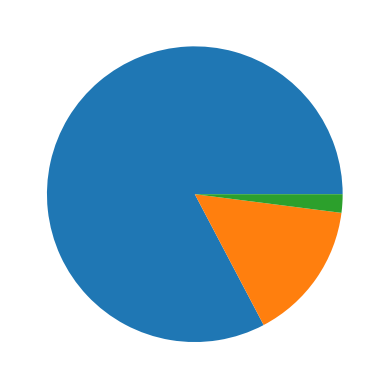

In [7]:
plt.pie(y.value_counts())

Для данной выборки будем использовать **oversampling**

In [8]:
sm = SMOTE(random_state = 42)

X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

**Логистическая регрессия**

In [9]:
def objective_logReg(trial):

    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    tol = trial.suggest_float('tol', 1e-5, 1e2, log = True)
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])
    max_iter = trial.suggest_int('max_iter', 1e2, 5e3, log = True)
    C = trial.suggest_float('C', 1e-3, 1e2, log = True)

    l1_ratio = None
    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0, 1)
    
    model = LogisticRegression(penalty = penalty, tol = tol, fit_intercept = fit_intercept, C = C,
                                max_iter = max_iter, solver = 'saga', l1_ratio = l1_ratio, random_state = RANDOM_STATE)

    # model.fit(X_train_resampled, y_train_resampled)

    # pred = model.predict(X_test)

    # return f1_score(y_test, pred, average='weighted')

    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)

    score = cross_val_score(model, X_train_resampled, y_train_resampled, cv = cv, scoring = "f1_weighted")

    return score.mean()

In [ ]:
study_logReg = optuna.create_study(direction = 'maximize')
study_logReg.optimize(objective_logReg, n_trials = 100)

best_model_logReg = LogisticRegression(**study_logReg.best_params, solver = 'saga', random_state = RANDOM_STATE)

best_model_logReg.fit(X_train_resampled, y_train_resampled)
best_pred_logReg = best_model_logReg.predict(X_test)


[I 2026-04-28 20:52:46,625] A new study created in memory with name: no-name-9e135a09-d29c-468f-9bde-244a253efdce
C:\Users\Chaizee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Chaizee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=None. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
[I 2026-04-28 20:53:16,037] Trial 0 finished with value: 0.6817298340719186 and

0.73758946729994


**KNN**

In [10]:
X_train_sub = X_train_resampled.sample(n=10000, random_state=RANDOM_STATE)
y_train_sub = y_train_resampled[X_train_sub.index]

def objective_KNN(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 15)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    leaf_size = trial.suggest_int('leaf_size', 10, 50)
    p = trial.suggest_int('p', 1, 2)

    model = KNeighborsClassifier(n_neighbors = n_neighbors, weights = weights, leaf_size = leaf_size, p = p, n_jobs=-1)

    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)

    score = cross_val_score(model, X_train_sub, y_train_sub, cv = cv, scoring='f1_weighted')

    return score.mean()

In [ ]:
study_KNN = optuna.create_study(direction = "maximize")
study_KNN.optimize(objective_KNN, n_trials = 10, show_progress_bar=True)

best_model_KNN = KNeighborsClassifier(**study_KNN.best_params)

best_model_KNN.fit(X_train_resampled, y_train_resampled)

best_pred_KNN = best_model_KNN.predict(X_test)

[I 2026-04-28 23:40:35,526] A new study created in memory with name: no-name-922dc06f-e57e-4106-a146-73cb3d425530


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-04-28 23:40:36,417] Trial 0 finished with value: 0.5450394947781725 and parameters: {'n_neighbors': 8, 'weights': 'uniform', 'leaf_size': 15, 'p': 1}. Best is trial 0 with value: 0.5450394947781725.
[I 2026-04-28 23:40:37,269] Trial 1 finished with value: 0.5948001048085514 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'leaf_size': 22, 'p': 1}. Best is trial 1 with value: 0.5948001048085514.
[I 2026-04-28 23:40:38,376] Trial 2 finished with value: 0.5387945931979715 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'leaf_size': 46, 'p': 2}. Best is trial 1 with value: 0.5948001048085514.
[I 2026-04-28 23:40:39,467] Trial 3 finished with value: 0.5338281246146486 and parameters: {'n_neighbors': 9, 'weights': 'uniform', 'leaf_size': 25, 'p': 2}. Best is trial 1 with value: 0.5948001048085514.
[I 2026-04-28 23:40:40,339] Trial 4 finished with value: 0.5522892351319918 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'leaf_size': 49, 'p': 1}. Best is tria

In [38]:
print(f1_score(best_pred_KNN, y_test, average = "weighted"))

0.5536862599273503


**Naive Bayes**

In [11]:
def objective_naive_bayes(trial):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-10, 1, log = True)

    model = GaussianNB(var_smoothing = var_smoothing)

    score = cross_val_score(model, X_train_resampled, y_train_resampled, cv = 5, scoring = 'f1_weighted').mean()

    return score

In [15]:
study_GaussianNB = optuna.create_study(direction = 'maximize')
study_GaussianNB.optimize(objective_naive_bayes, n_trials = 20)

best_model_GaussianNB = GaussianNB(**study_GaussianNB.best_params)

best_model_GaussianNB.fit(X_train_resampled, y_train_resampled)

best_pred_GaussianNB = best_model_GaussianNB.predict(X_test)

[I 2026-05-04 12:11:27,976] A new study created in memory with name: no-name-29b430ba-b28d-4cf5-9903-f9d9eaa98fce
[I 2026-05-04 12:11:29,135] Trial 0 finished with value: 0.4513503980026572 and parameters: {'var_smoothing': 6.773097108617681e-07}. Best is trial 0 with value: 0.4513503980026572.
[I 2026-05-04 12:11:30,231] Trial 1 finished with value: 0.471623541372833 and parameters: {'var_smoothing': 3.477718568096881e-05}. Best is trial 1 with value: 0.471623541372833.
[I 2026-05-04 12:11:31,314] Trial 2 finished with value: 0.45087005272269903 and parameters: {'var_smoothing': 8.549132151672184e-08}. Best is trial 1 with value: 0.471623541372833.
[I 2026-05-04 12:11:32,420] Trial 3 finished with value: 0.45079724094524004 and parameters: {'var_smoothing': 1.1993512243394545e-10}. Best is trial 1 with value: 0.471623541372833.
[I 2026-05-04 12:11:33,496] Trial 4 finished with value: 0.5061342572042598 and parameters: {'var_smoothing': 0.00019468415845575062}. Best is trial 4 with val

In [16]:
print(f1_score(best_pred_GaussianNB, y_test , average = 'weighted'))

0.5334650492914168


**SVM**

In [14]:
X_train_sub = X_train_resampled.sample(n=10000, random_state=RANDOM_STATE)
y_train_sub = y_train_resampled[X_train_sub.index]

def objective_svc(trial):
    C = trial.suggest_float('C', 1e-3, 1e3, log = True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])

    params = {'C': C, 'kernel': kernel}
    if kernel in ['rbf', 'poly', 'sigmoid']:
        params['gamma'] = trial.suggest_float('gamma', 1e-4, 10, log = True)

    if kernel == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)

    model = SVC(**params)

    score = cross_val_score(model, X_train_sub, y_train_sub, cv = 5, scoring = 'f1_weighted').mean()

    return score

In [ ]:
study_svc = optuna.create_study(direction = 'maximize')
study_svc.optimize(objective_svc, n_trials = 10)

best_model_SVC = SVC(**study_svc.best_params)

best_model_SVC.fit(X_train_resampled, y_train_resampled)

best_pred_SVC = best_model_SVC.predict(X_test)


[I 2026-05-04 12:50:03,181] A new study created in memory with name: no-name-0c517cc8-6c39-42d2-a84d-d03ba533224b


In [ ]:
print(f1_score(best_pred_SVC, y_test, average = 'weighted'))